# Grover's Algorithm: Searching with Wave Interference

This is the course's first real quantum algorithm, and it is the gentlest. The next lesson, Shor's, turns factoring into period finding through dense quantum machinery; Grover's shows the **core quantum mechanic** in a way you can watch on a bar chart.

The problem is the simplest one imaginable: **unstructured search**. You have `N` items and a way to recognize the one you want (an *oracle* that says "yes, that's it" or "no"), but no structure - no sorting, no index - to exploit. Classically you have no choice but to try items one at a time: `N` checks in the worst case, `N/2` on average. For a million items that is half a million tries.

Grover's algorithm finds it in about `(pi/4) * sqrt(N)` steps - roughly **785 for a million items**. The speedup is not magic and it is not "checking all paths at once." A quantum computer can hold all `N` possibilities in **superposition**, but measuring that superposition just returns a random one. Grover's insight is to spend a few rounds using **interference** - nudging amplitudes up and down - to drain probability out of the wrong answers and pile it onto the right one *before* you measure.


## 1. State as a Vector of Amplitudes

We will simulate a small quantum system as a plain vector of real **amplitudes**, one per basis state. With 3 qubits there are `2^3 = 8` states, labelled 0 through 7. The probability of measuring a state is its amplitude **squared**, and those probabilities must sum to one.

We start in a **uniform superposition**: every state shares the same amplitude `1/sqrt(N)`, so every state is equally likely. One state - say number 5 - is the secret answer the oracle recognizes.


**Imports and setup.** Arrays, plotting, animation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

N_QUBITS = 3
N = 2 ** N_QUBITS        # 8 states
TARGET = 5               # the marked answer the oracle recognizes


**Uniform superposition.** Equal amplitude in every state; probabilities sum to one.


In [2]:
def uniform_state(n):
    return np.full(n, 1.0 / np.sqrt(n))


amp = uniform_state(N)
print("amplitudes:", amp.round(3))
print("probabilities:", (amp ** 2).round(3))
print("sum of probabilities:", round(float(np.sum(amp ** 2)), 6))


amplitudes: [0.354 0.354 0.354 0.354 0.354 0.354 0.354 0.354]
probabilities: [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
sum of probabilities: 1.0


## 2. The Two Moves

One **Grover iteration** is two reflections applied to the amplitude vector.

**The oracle** flips the *sign* of the marked state's amplitude and leaves the rest alone. It does not increase any probability (squaring removes the sign); it just marks the target by making it negative. This is the only place the secret answer enters.

**Inversion about the mean** (the diffusion step) reflects every amplitude about the current average: `a -> 2*mean - a`. After the oracle has pushed the target *below* the average, this reflection sends it shooting *above* the average while pulling the others down. That is the interference that amplifies the answer.


**Oracle and diffusion.** Each is a reflection; together they make one Grover iteration.


In [3]:
def oracle(amp, target):
    out = amp.copy()
    out[target] = -out[target]          # phase-flip the marked state
    return out


def diffusion(amp):
    mean = amp.mean()
    return 2 * mean - amp               # reflect every amplitude about the mean


def grover_iteration(amp, target):
    return diffusion(oracle(amp, target))


# one iteration on the uniform state
step1 = grover_iteration(uniform_state(N), TARGET)
print("after 1 iteration, probabilities:", (step1 ** 2).round(3))
print("target probability:", round(float(step1[TARGET] ** 2), 4))


after 1 iteration, probabilities: [0.031 0.031 0.031 0.031 0.031 0.781 0.031 0.031]
target probability: 0.7812


## 3. Watch the Target Grow

Record the amplitudes after each iteration so we can replay them. On 8 states the target probability climbs `0.125 -> 0.781 -> 0.945` over the first two iterations.


**Run and record.** Capture a replayable history of amplitude vectors.


In [4]:
def grover_run(n, target, iterations):
    amp = uniform_state(n)
    history = [amp.copy()]
    for _ in range(iterations):
        amp = grover_iteration(amp, target)
        history.append(amp.copy())
    return history


history = grover_run(N, TARGET, 6)
for k, a in enumerate(history):
    print(f"k={k}: target probability = {a[TARGET] ** 2:.4f}")


k=0: target probability = 0.1250
k=1: target probability = 0.7812
k=2: target probability = 0.9453
k=3: target probability = 0.3301
k=4: target probability = 0.0122
k=5: target probability = 0.5480
k=6: target probability = 0.9998


**Bar chart.** Probabilities after 0, 1, and 2 iterations; the dashed line is the mean each reflection folds around.


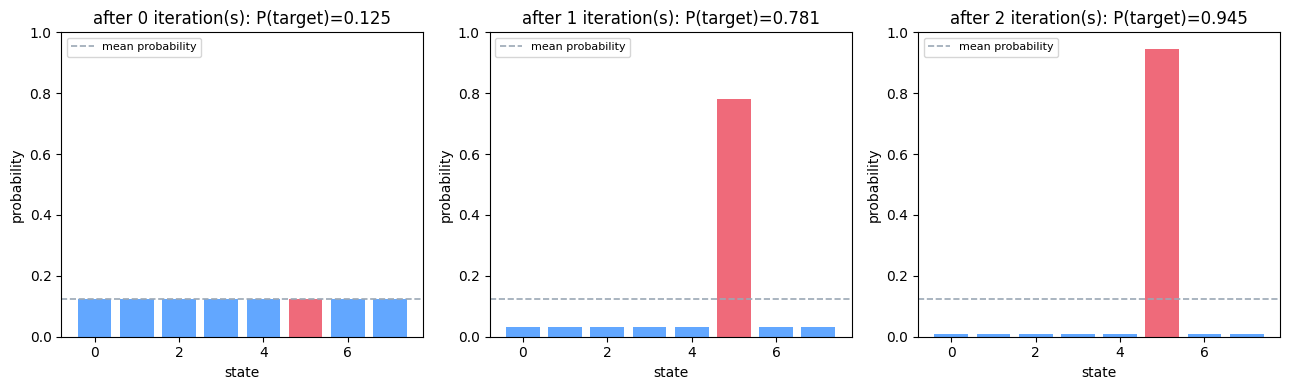

In [5]:
def draw_bars(ax, amp, title):
    probs = amp ** 2
    colors = ["#ef6a7a" if i == TARGET else "#62a7ff" for i in range(len(amp))]
    ax.bar(range(len(amp)), probs, color=colors)
    ax.axhline(probs.mean(), color="#9ba8b5", ls="--", lw=1.2, label="mean probability")
    ax.set_ylim(0, 1)
    ax.set_xlabel("state")
    ax.set_ylabel("probability")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, k in zip(axes, (0, 1, 2)):
    draw_bars(ax, history[k], f"after {k} iteration(s): P(target)={history[k][TARGET] ** 2:.3f}")
plt.tight_layout()
plt.show()


**Animation.** Replay the amplitudes iteration by iteration. The target (red) rises to a peak at k=2, then *falls* - the probability oscillates, so you must stop at the first peak.


In [6]:
def animate_grover(history):
    fig, ax = plt.subplots(figsize=(7, 4.5))

    def update(k):
        ax.clear()
        draw_bars(ax, history[k], f"iteration {k}: P(target) = {history[k][TARGET] ** 2:.3f}")

    anim = animation.FuncAnimation(fig, update, frames=len(history), interval=900)
    plt.close(fig)
    return HTML(anim.to_jshtml())


animate_grover(history)


## 4. Why Square-Root? The Rotation Picture

The amplitudes only ever mix two directions: the marked answer `|target>`, and the even blend of all the wrong answers `|rest>`. So the whole state lives in a **2D plane**, and it starts as a vector at a small angle `theta` above the `|rest>` axis, where `sin(theta) = 1/sqrt(N)`.

Here is the elegant part: oracle-then-diffusion is two reflections, and two reflections equal a **rotation**. Each Grover iteration rotates the state by `2*theta` toward `|target>`. After `k` iterations the angle is `(2k+1)*theta`, so the success probability is exactly `sin^2((2k+1)*theta)`.

Reaching the `|target>` axis (90 degrees) means certain success. Since each step turns by `2*theta` and `theta ~ 1/sqrt(N)` for large `N`, it takes about `(pi/4)*sqrt(N)` steps to get there - the square-root speedup. Rotate too far and you swing *past* the target.


**The rotating state.** Each iteration turns the state vector by `2*theta`; k=2 lands near the target axis, k=3 has over-rotated past it.


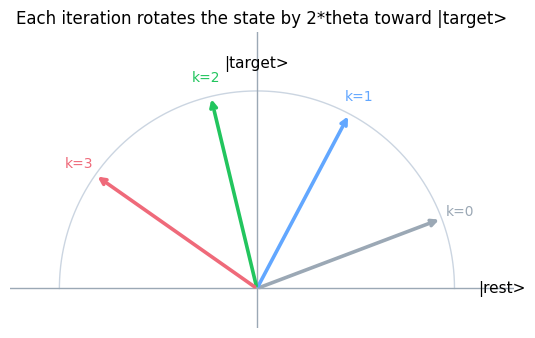

In [7]:
theta = np.arcsin(1 / np.sqrt(N))
arc = np.linspace(0, np.pi, 200)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(np.cos(arc), np.sin(arc), color="#cbd5e1", lw=1)
ax.axhline(0, color="#9ba8b5", lw=1)
ax.axvline(0, color="#9ba8b5", lw=1)
colors = ["#9ba8b5", "#62a7ff", "#22c55e", "#ef6a7a"]
for k, c in enumerate(colors):
    angle = (2 * k + 1) * theta
    ax.annotate("", xy=(np.cos(angle), np.sin(angle)), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=c, lw=2.6))
    ax.text(np.cos(angle) * 1.1, np.sin(angle) * 1.1, f"k={k}", color=c, ha="center", va="center")
ax.text(1.12, 0, "|rest>", va="center", fontsize=11)
ax.text(0, 1.12, "|target>", ha="center", fontsize=11)
ax.set_aspect("equal")
ax.set_xlim(-1.25, 1.3)
ax.set_ylim(-0.2, 1.3)
ax.axis("off")
ax.set_title("Each iteration rotates the state by 2*theta toward |target>")
plt.show()


## 5. The Square-Root Speedup

The first peak sits near `k = (pi/4)*sqrt(N)`. That is what turns a linear scan into a square-root one: the number of iterations grows like `sqrt(N)`, not `N`.


**Optimal iterations and speedup.** Compare Grover's first-peak iteration count with the classical average of `N/2` checks.


In [8]:
def optimal_iterations(n):
    return int(round((np.pi / 4) * np.sqrt(n) - 0.5))


print(f"{'N':>10} | {'Grover k':>9} | {'classical N/2':>13} | speedup")
for n in (8, 16, 64, 1024, 1_000_000):
    k = optimal_iterations(n)
    classical = n // 2
    print(f"{n:>10} | {k:>9} | {classical:>13} | ~{classical / max(k, 1):.0f}x")


         N |  Grover k | classical N/2 | speedup
         8 |         2 |             4 | ~2x
        16 |         3 |             8 | ~3x
        64 |         6 |            32 | ~5x
      1024 |        25 |           512 | ~20x
   1000000 |       785 |        500000 | ~637x


**The square-root law.** Optimal iteration count plotted against `sqrt(N)` is a straight line.


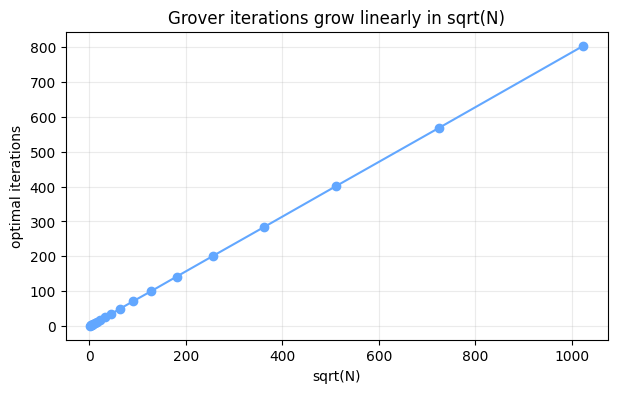

In [9]:
sizes = [2 ** b for b in range(2, 21)]
opt = [optimal_iterations(n) for n in sizes]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.sqrt(sizes), opt, marker="o", color="#62a7ff")
ax.set_xlabel("sqrt(N)")
ax.set_ylabel("optimal iterations")
ax.set_title("Grover iterations grow linearly in sqrt(N)")
ax.grid(alpha=0.25)
plt.show()


## 6. Failure Mode: Over-Rotation

The rotation does not stop at the target; it keeps going. If you apply **too many** iterations you swing past `|target>` and the success probability **falls**. More is not better - the algorithm must stop at the first peak near `(pi/4)*sqrt(N)`.

On 8 states the peak is at `k=2` (0.945). Run a few more and watch it drop, bottom out, then swing back up - a periodic oscillation, not a climb.


**Over-rotation curve.** Success probability versus iteration count; it oscillates rather than converging.


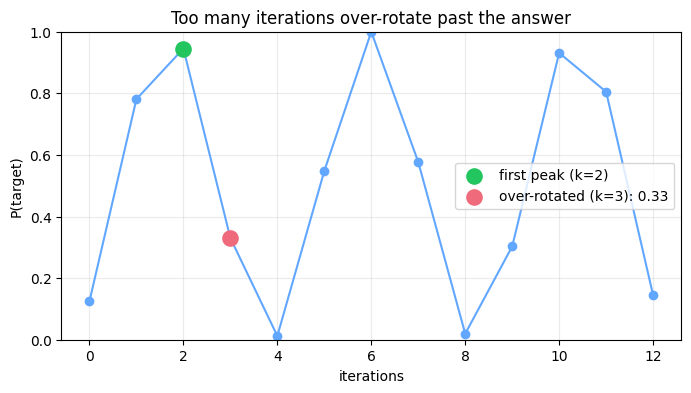

In [10]:
long_run = grover_run(N, TARGET, 12)
probs = [a[TARGET] ** 2 for a in long_run]
best = optimal_iterations(N)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(probs)), probs, marker="o", color="#62a7ff")
ax.scatter([best], [probs[best]], s=120, color="#22c55e", zorder=5, label=f"first peak (k={best})")
ax.scatter([3], [probs[3]], s=120, color="#ef6a7a", zorder=5, label=f"over-rotated (k=3): {probs[3]:.2f}")
ax.set_xlabel("iterations")
ax.set_ylabel("P(target)")
ax.set_ylim(0, 1)
ax.set_title("Too many iterations over-rotate past the answer")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 7. Mini-Challenge

Try one:

1. Change `TARGET` to a different state and confirm the curve is identical - Grover does not care *which* state is marked, only that one is.
2. Use 4 qubits (`N = 16`). What is the optimal iteration count, and what success probability does it reach?
3. Mark **two** states (flip both signs in the oracle). How does `theta`, and the optimal iteration count, change?
4. Find the smallest `N` for which over-rotation at `k = optimal + 1` drops success below 50 percent.
5. From the rotation picture, derive `(pi/4)*sqrt(N)` directly: how many turns of `2*theta` reach 90 degrees when `theta ~ 1/sqrt(N)`?


**Invariant check.** Amplitudes stay unit-normalized, and the simulation matches the closed form `sin^2((2k+1)*theta)`.


In [11]:
norms_ok = all(abs(float(np.sum(a ** 2)) - 1.0) < 1e-12 for a in history)
print("probabilities sum to one after every iteration:", norms_ok)

theta = np.arcsin(1 / np.sqrt(N))
closed_form_ok = all(
    abs(a[TARGET] ** 2 - np.sin((2 * k + 1) * theta) ** 2) < 1e-9
    for k, a in enumerate(history)
)
print("simulation matches sin^2((2k+1)*theta):", closed_form_ok)


probabilities sum to one after every iteration: True
simulation matches sin^2((2k+1)*theta): True


## Visual Trace + Rigor Studio

**Problem frame.** Find the single marked item among `N` with no structure to exploit, using a quantum computer that can hold all states at once but collapses to a random one when measured.

**Interactive animation target.** Animate the probability bar chart across iterations with the mean line drawn, so the oracle-and-diffusion step is visibly an "inversion about the mean"; controls for the number of qubits, the marked state, and the iteration count.

**Correctness handle.** Amplitudes stay unit-normalized; the state stays in the 2D plane spanned by `|target>` and `|rest>`; after `k` iterations the success probability is exactly `sin^2((2k+1)*theta)` with `sin(theta) = 1/sqrt(N)`.

**Complexity handle.** The first peak is at `k ~ (pi/4)*sqrt(N)`, so Grover uses `O(sqrt(N))` oracle queries against the classical `O(N)`; for `N = 10^6` that is about 785 iterations versus 500,000 average checks.

**Failure mode to test.** Apply more than the optimal number of iterations. The state rotates past `|target>` and the success probability falls - it oscillates rather than converging, so over-running the algorithm makes it worse.

**Studio task.** Find the optimal iteration count for `N = 8` (2) and `N = 16` (3), then deliberately over-rotate and plot the oscillating success probability against iteration count.

**Transfer.** Grover reshapes a probability distribution by interference, the same representation-change idea behind the Fast Fourier Transform (Module 4) and Shor's period finding (the next lesson). It contrasts with the classical linear scan and with the sampling search of Monte Carlo Tree Search (Module 5).


## Sources and Further Reading

- Lov K. Grover, [A Fast Quantum Mechanical Algorithm for Database Search](https://doi.org/10.1145/237814.237866), STOC 1996 - the original algorithm.
- Michael A. Nielsen and Isaac L. Chuang, *Quantum Computation and Quantum Information* (2010), chapter 6 - quantum search and amplitude amplification.
- Gilles Brassard, Peter Hoyer, Michele Mosca, and Alain Tapp, [Quantum Amplitude Amplification and Estimation](https://doi.org/10.1090/conm/305/05215) - the general framework behind Grover.

This is a transparent teaching simulation using real amplitude vectors. A physical quantum computer represents the same amplitudes in qubit hardware and applies the oracle and diffusion as quantum gates.
